In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Load data once
trips_df = pd.read_parquet("dataset/all_trips.parquet")

# Trip duration

- Casual users ride more than 2X longer trips than member users.
- Casual users ride 2X longer trips in classic bikes that ebikes.
- Members share a similar bike ride duration between classic and electric bikes.


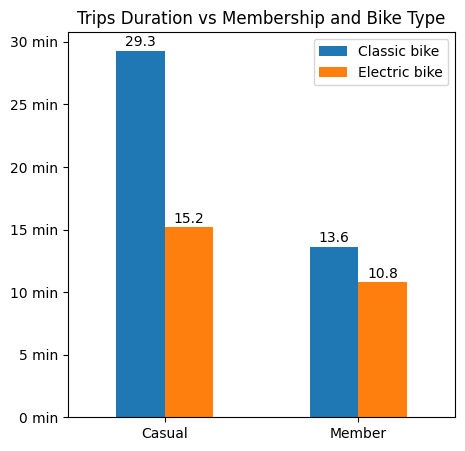

In [18]:
duration_mean = (trips_df.groupby(['is_member', 'rideable_type'])['duration'].mean() / 60).to_frame(name='avg_duration_mins')
duration_mean_unstacked = duration_mean.unstack(level='rideable_type')

ax = duration_mean_unstacked.plot(kind='bar', figsize=(5, 5), stacked=False)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=1)

ax.set_xticklabels(["Casual", "Member"])
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f} min'))

plt.title('Trips Duration vs Membership and Bike Type')
plt.ylabel('')

plt.legend(['Classic bike', 'Electric bike'])
plt.xticks(rotation=0)
plt.xlabel('')
plt.show()

# Number of Rides per Weekday

- Members start more rides in weekdays while casual users ride more on weekends.

Text(0.5, 1.0, 'Rides by Day of Week: Members vs Casuals')

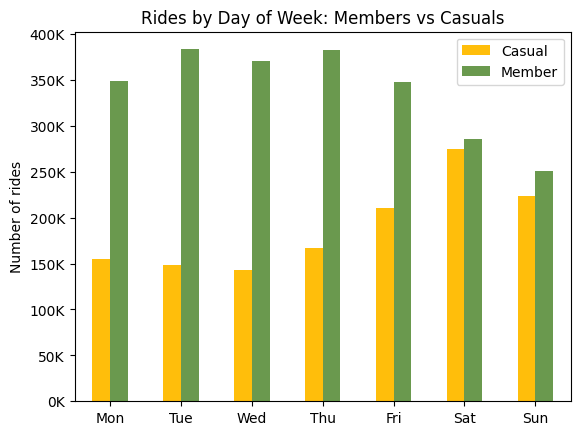

In [23]:
number_of_rides = trips_df.groupby(['day_of_week', 'is_member']).size().unstack() / 1000
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
number_of_rides = number_of_rides.reindex(days_order)

ax = number_of_rides.plot(kind='bar', color=['#ffbe0b','#6a994e'])
ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xticks(rotation=0)
plt.xlabel('')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0f}K'))
plt.ylabel('Number of rides')
plt.legend(['Casual', 'Member'])
ax.set_title('Rides by Day of Week: Members vs Casuals')